In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load data
clean_data = pd.read_csv('../data/clean_data.csv')
movies     = pd.read_csv('../data/ml-latest-small/movies.csv')

# Load both models
with open('../models/collab_similarity.pkl', 'rb') as f:
    collab_similarity_df = pickle.load(f)

with open('../models/content_similarity.pkl', 'rb') as f:
    content_similarity_df = pickle.load(f)

print("✅ Everything loaded!")
print(f"Clean data shape:       {clean_data.shape}")
print(f"Collab matrix shape:    {collab_similarity_df.shape}")
print(f"Content matrix shape:   {content_similarity_df.shape}")

✅ Everything loaded!
Clean data shape:       (100836, 5)
Collab matrix shape:    (9719, 9719)
Content matrix shape:   (9742, 9742)


In [2]:
def hybrid_recommend(movie_title, n_recommendations=10, 
                     collab_weight=0.5, content_weight=0.5):
    """
    Hybrid recommendation combining collaborative and content-based filtering.
    collab_weight + content_weight must equal 1.0
    """
    if movie_title not in collab_similarity_df.columns and \
       movie_title not in content_similarity_df.columns:
        print(f"❌ '{movie_title}' not found in either model.")
        return None

    scores = {}

    # Collaborative scores
    if movie_title in collab_similarity_df.columns:
        collab_scores = (
            collab_similarity_df[movie_title]
            .drop(movie_title)
        )
        # Normalise to 0-1
        min_val = collab_scores.min()
        max_val = collab_scores.max()
        if max_val > min_val:
            collab_scores = (collab_scores - min_val) / (max_val - min_val)
        for title, score in collab_scores.items():
            scores[title] = scores.get(title, 0) + collab_weight * score

    # Content scores
    if movie_title in content_similarity_df.columns:
        content_scores = (
            content_similarity_df[movie_title]
            .drop(movie_title)
        )
        # Normalise to 0-1
        min_val = content_scores.min()
        max_val = content_scores.max()
        if max_val > min_val:
            content_scores = (content_scores - min_val) / (max_val - min_val)
        for title, score in content_scores.items():
            scores[title] = scores.get(title, 0) + content_weight * score

    # Sort and return top N
    top_movies = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_movies = [(t, s) for t, s in top_movies if t != movie_title][:n_recommendations]

    print(f"\n🎬 Hybrid recommendations for '{movie_title}':")
    print(f"   (Collab weight: {collab_weight} | Content weight: {content_weight})")
    print("-" * 60)
    for i, (title, score) in enumerate(top_movies, 1):
        print(f"{i:2}. {title:<48} ({score:.4f})")

    return top_movies

In [3]:
hybrid_recommend('Toy Story (1995)')


🎬 Hybrid recommendations for 'Toy Story (1995)':
   (Collab weight: 0.5 | Content weight: 0.5)
------------------------------------------------------------
 1. Toy Story 2 (1999)                               (0.9978)
 2. Monsters, Inc. (2001)                            (0.9388)
 3. Shrek (2001)                                     (0.8885)
 4. Finding Nemo (2003)                              (0.8235)
 5. Bug's Life, A (1998)                             (0.8183)
 6. Antz (1998)                                      (0.8104)
 7. Aladdin (1992)                                   (0.7896)
 8. Incredibles, The (2004)                          (0.7796)
 9. Toy Story 3 (2010)                               (0.7541)
10. Emperor's New Groove, The (2000)                 (0.7398)


[('Toy Story 2 (1999)', 0.9977559311073787),
 ('Monsters, Inc. (2001)', 0.9388062274928876),
 ('Shrek (2001)', 0.8884960805156132),
 ('Finding Nemo (2003)', 0.8235087481029444),
 ("Bug's Life, A (1998)", 0.8183306169929976),
 ('Antz (1998)', 0.8104400968433809),
 ('Aladdin (1992)', 0.7896217258826623),
 ('Incredibles, The (2004)', 0.7795968670430116),
 ('Toy Story 3 (2010)', 0.7540531365776136),
 ("Emperor's New Groove, The (2000)", 0.7397885402558629)]

In [4]:
hybrid_recommend('Forrest Gump (1994)')


🎬 Hybrid recommendations for 'Forrest Gump (1994)':
   (Collab weight: 0.5 | Content weight: 0.5)
------------------------------------------------------------
 1. Life Is Beautiful (La Vita è bella) (1997)       (0.7413)
 2. Sleepless in Seattle (1993)                      (0.6072)
 3. English Patient, The (1996)                      (0.5807)
 4. Mrs. Doubtfire (1993)                            (0.5776)
 5. Shawshank Redemption, The (1994)                 (0.5642)
 6. Braveheart (1995)                                (0.5582)
 7. Good Will Hunting (1997)                         (0.5579)
 8. Gone with the Wind (1939)                        (0.5541)
 9. As Good as It Gets (1997)                        (0.5502)
10. American Beauty (1999)                           (0.5474)


[('Life Is Beautiful (La Vita è bella) (1997)', 0.7413440561600091),
 ('Sleepless in Seattle (1993)', 0.6072183740537929),
 ('English Patient, The (1996)', 0.5806944502271757),
 ('Mrs. Doubtfire (1993)', 0.5775544777114993),
 ('Shawshank Redemption, The (1994)', 0.564225023216671),
 ('Braveheart (1995)', 0.5581839540905297),
 ('Good Will Hunting (1997)', 0.5579060908037679),
 ('Gone with the Wind (1939)', 0.5540638419134603),
 ('As Good as It Gets (1997)', 0.5502251638875926),
 ('American Beauty (1999)', 0.547430312736839)]

In [5]:
hybrid_recommend('Pulp Fiction (1994)')


🎬 Hybrid recommendations for 'Pulp Fiction (1994)':
   (Collab weight: 0.5 | Content weight: 0.5)
------------------------------------------------------------
 1. Confessions of a Dangerous Mind (2002)           (0.9848)
 2. Fargo (1996)                                     (0.9283)
 3. Léon: The Professional (a.k.a. The Professional) (Léon) (1994) (0.7870)
 4. Shawshank Redemption, The (1994)                 (0.7765)
 5. Fight Club (1999)                                (0.7456)
 6. Trainspotting (1996)                             (0.7448)
 7. In Bruges (2008)                                 (0.7166)
 8. Taxi Driver (1976)                               (0.7063)
 9. Clear and Present Danger (1994)                  (0.7035)
10. Departed, The (2006)                             (0.6759)


[('Confessions of a Dangerous Mind (2002)', 0.9847652213509854),
 ('Fargo (1996)', 0.9282926374196974),
 ('Léon: The Professional (a.k.a. The Professional) (Léon) (1994)',
  0.78700906583449),
 ('Shawshank Redemption, The (1994)', 0.7764804738297925),
 ('Fight Club (1999)', 0.7455599165328217),
 ('Trainspotting (1996)', 0.7447967606049154),
 ('In Bruges (2008)', 0.716591545444936),
 ('Taxi Driver (1976)', 0.7063278547612533),
 ('Clear and Present Danger (1994)', 0.7034735887047485),
 ('Departed, The (2006)', 0.6758864794345095)]

In [6]:
def compare_all_models(movie_title, n=5):
    print(f"\n{'='*65}")
    print(f"  Movie: {movie_title}")
    print(f"{'='*65}")

    # Collaborative
    print(f"\n📊 Collaborative Filtering:")
    if movie_title in collab_similarity_df.columns:
        collab = (
            collab_similarity_df[movie_title]
            .sort_values(ascending=False)
            .drop(movie_title).head(n)
        )
        for i, (t, s) in enumerate(collab.items(), 1):
            print(f"  {i}. {t:<48} ({s:.4f})")

    # Content-based
    print(f"\n🎬 Content-Based Filtering:")
    if movie_title in content_similarity_df.columns:
        content = (
            content_similarity_df[movie_title]
            .sort_values(ascending=False)
            .drop(movie_title).head(n)
        )
        for i, (t, s) in enumerate(content.items(), 1):
            print(f"  {i}. {t:<48} ({s:.4f})")

    # Hybrid
    print(f"\n🔀 Hybrid Model (50/50 blend):")
    results = hybrid_recommend(movie_title, n_recommendations=n,
                               collab_weight=0.5, content_weight=0.5)

compare_all_models('Toy Story (1995)')
compare_all_models('Forrest Gump (1994)')


  Movie: Toy Story (1995)

📊 Collaborative Filtering:
  1. Toy Story 2 (1999)                               (0.5726)
  2. Jurassic Park (1993)                             (0.5656)
  3. Independence Day (a.k.a. ID4) (1996)             (0.5643)
  4. Star Wars: Episode IV - A New Hope (1977)        (0.5574)
  5. Forrest Gump (1994)                              (0.5471)

🎬 Content-Based Filtering:
  1. Tale of Despereaux, The (2008)                   (0.8785)
  2. Asterix and the Vikings (Astérix et les Vikings) (2006) (0.8767)
  3. Wild, The (2006)                                 (0.8767)
  4. Monsters, Inc. (2001)                            (0.8753)
  5. The Good Dinosaur (2015)                         (0.8748)

🔀 Hybrid Model (50/50 blend):

🎬 Hybrid recommendations for 'Toy Story (1995)':
   (Collab weight: 0.5 | Content weight: 0.5)
------------------------------------------------------------
 1. Toy Story 2 (1999)                               (0.9978)
 2. Monsters, Inc. (2001)     

In [18]:
print("⭐ Finding optimal hybrid weights using KFold cross-validation...")
print("This may take a few minutes — please wait.\n")

# Define weight combinations to test
weight_combinations = [
    (0.1, 0.9), (0.2, 0.8), (0.3, 0.7),
    (0.4, 0.6), (0.5, 0.5), (0.6, 0.4),
    (0.7, 0.3), (0.8, 0.2), (0.9, 0.1)
]

def predict_hybrid_rating(movie_title, collab_sim, content_sim,
                           clean_data, cw, contw, n=10):
    """Predict rating using weighted hybrid of both models."""
    global_mean = clean_data['rating'].mean()

    collab_score  = 0
    content_score = 0
    collab_found  = False
    content_found = False

    # Collaborative prediction
    if movie_title in collab_sim.columns:
        sim_series = collab_sim[movie_title]
        if isinstance(sim_series, pd.DataFrame):
            sim_series = sim_series.iloc[:, 0]
        similar = sim_series.sort_values(ascending=False).drop(movie_title).head(n)
        ratings_sum = 0
        weight_sum  = 0
        for t in similar.index:
            r = clean_data[clean_data['title'] == t]['rating']
            if len(r) > 0:
                ratings_sum += similar[t] * r.mean()
                weight_sum  += similar[t]
        if weight_sum > 0:
            collab_score = ratings_sum / weight_sum
            collab_found = True

    # Content prediction
    if movie_title in content_sim.columns:
        sim_series = content_sim[movie_title]
        if isinstance(sim_series, pd.DataFrame):
            sim_series = sim_series.iloc[:, 0]
        similar = sim_series.sort_values(ascending=False).drop(movie_title).head(n)
        ratings_sum = 0
        weight_sum  = 0
        for t in similar.index:
            r = clean_data[clean_data['title'] == t]['rating']
            if len(r) > 0:
                ratings_sum += similar[t] * r.mean()
                weight_sum  += similar[t]
        if weight_sum > 0:
            content_score = ratings_sum / weight_sum
            content_found = True

    # Blend
    if collab_found and content_found:
        return cw * collab_score + contw * content_score
    elif collab_found:
        return collab_score
    elif content_found:
        return content_score
    else:
        return global_mean

# KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
sample_data = clean_data.sample(300, random_state=42).reset_index(drop=True)
results     = {}

for cw, contw in weight_combinations:
    fold_rmses = []

    for train_idx, test_idx in kf.split(sample_data):
        train_fold = sample_data.iloc[train_idx]
        test_fold  = sample_data.iloc[test_idx]

        actuals     = []
        predictions = []

        for _, row in test_fold.iterrows():
            pred = predict_hybrid_rating(
                row['title'],
                collab_similarity_df,
                content_similarity_df,
                train_fold, cw, contw
            )
            actuals.append(row['rating'])
            predictions.append(pred)

        fold_rmse = np.sqrt(mean_squared_error(actuals, predictions))
        fold_rmses.append(fold_rmse)

    avg_rmse = np.mean(fold_rmses)
    results[(cw, contw)] = avg_rmse
    print(f"  Collab: {cw:.1f} | Content: {contw:.1f} → RMSE: {avg_rmse:.4f}")

# Find best weights
best_weights = min(results, key=results.get)
best_rmse    = results[best_weights]

print(f"\n✅ Best weights found!")
print(f"   Collaborative: {best_weights[0]}")
print(f"   Content-based: {best_weights[1]}")
print(f"   RMSE:          {best_rmse:.4f}")

⭐ Finding optimal hybrid weights using KFold cross-validation...
This may take a few minutes — please wait.

  Collab: 0.1 | Content: 0.9 → RMSE: 1.1292
  Collab: 0.2 | Content: 0.8 → RMSE: 1.1250
  Collab: 0.3 | Content: 0.7 → RMSE: 1.1224
  Collab: 0.4 | Content: 0.6 → RMSE: 1.1215
  Collab: 0.5 | Content: 0.5 → RMSE: 1.1222
  Collab: 0.6 | Content: 0.4 → RMSE: 1.1246
  Collab: 0.7 | Content: 0.3 → RMSE: 1.1287
  Collab: 0.8 | Content: 0.2 → RMSE: 1.1343
  Collab: 0.9 | Content: 0.1 → RMSE: 1.1416

✅ Best weights found!
   Collaborative: 0.4
   Content-based: 0.6
   RMSE:          1.1215


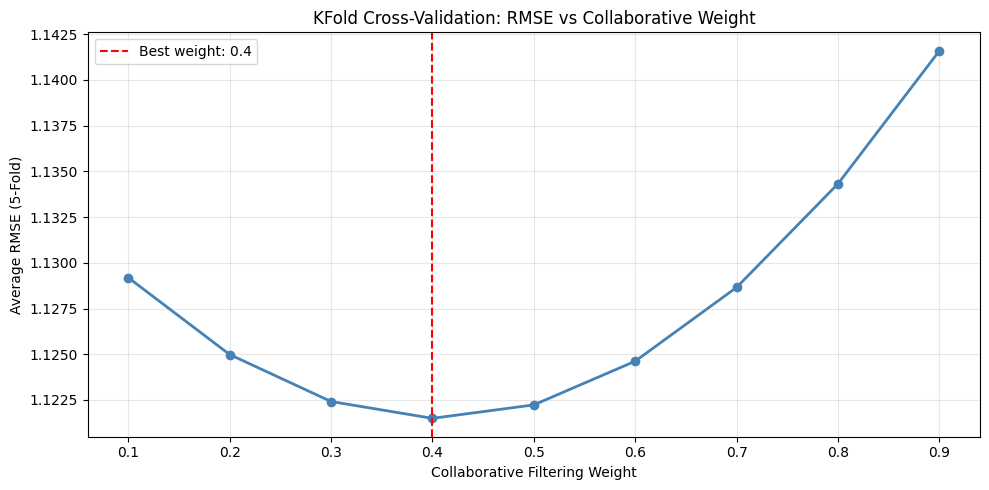

✅ Chart saved!


In [8]:
cw_vals   = [k[0] for k in results.keys()]
rmse_vals = list(results.values())

plt.figure(figsize=(10, 5))
plt.plot(cw_vals, rmse_vals, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_weights[0], color='red', linestyle='--',
            label=f'Best weight: {best_weights[0]}')
plt.title('KFold Cross-Validation: RMSE vs Collaborative Weight')
plt.xlabel('Collaborative Filtering Weight')
plt.ylabel('Average RMSE (5-Fold)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/kfold_weights.png')
plt.show()
print("✅ Chart saved!")

In [9]:
BEST_COLLAB_WEIGHT   = best_weights[0]
BEST_CONTENT_WEIGHT  = best_weights[1]

print(f"Using optimal weights: {BEST_COLLAB_WEIGHT}/{BEST_CONTENT_WEIGHT}")

hybrid_recommend(
    'Toy Story (1995)',
    collab_weight=BEST_COLLAB_WEIGHT,
    content_weight=BEST_CONTENT_WEIGHT
)

Using optimal weights: 0.4/0.6

🎬 Hybrid recommendations for 'Toy Story (1995)':
   (Collab weight: 0.4 | Content weight: 0.6)
------------------------------------------------------------
 1. Toy Story 2 (1999)                               (0.9973)
 2. Monsters, Inc. (2001)                            (0.9503)
 3. Shrek (2001)                                     (0.8818)
 4. Antz (1998)                                      (0.8466)
 5. Finding Nemo (2003)                              (0.8191)
 6. Bug's Life, A (1998)                             (0.8146)
 7. Emperor's New Groove, The (2000)                 (0.7906)
 8. Incredibles, The (2004)                          (0.7724)
 9. Aladdin (1992)                                   (0.7632)
10. Toy Story 3 (2010)                               (0.7592)


[('Toy Story 2 (1999)', 0.9973071173288545),
 ('Monsters, Inc. (2001)', 0.9503017324323992),
 ('Shrek (2001)', 0.8817818715237294),
 ('Antz (1998)', 0.8465582772211493),
 ('Finding Nemo (2003)', 0.8190535332063134),
 ("Bug's Life, A (1998)", 0.8146059770453704),
 ("Emperor's New Groove, The (2000)", 0.7906431450407625),
 ('Incredibles, The (2004)', 0.7724427317015989),
 ('Aladdin (1992)', 0.7631737328815353),
 ('Toy Story 3 (2010)', 0.7591813524131925)]

In [10]:
def get_popular_movies(clean_data, n=10):
    """
    Cold start fallback — returns most popular movies
    for brand new users with no rating history.
    Popular = highest number of ratings AND good average rating.
    """
    popular = (
        clean_data.groupby('title')['rating']
        .agg(['count', 'mean'])
        .rename(columns={'count': 'num_ratings', 'mean': 'avg_rating'})
    )

    # Filter movies with at least 50 ratings
    popular = popular[popular['num_ratings'] >= 50]

    # Score = avg_rating weighted by number of ratings
    popular['popularity_score'] = (
        popular['avg_rating'] * np.log1p(popular['num_ratings'])
    )

    top_popular = popular.sort_values(
        'popularity_score', ascending=False
    ).head(n)

    return top_popular

def new_user_recommend(n=10):
    """
    Recommendation for a completely new user with no history.
    Falls back to popular/trending content as per supervisor recommendation.
    """
    print("👤 New user detected — no rating history available.")
    print("📈 Showing popular and highly-rated movies as recommendations:\n")

    popular = get_popular_movies(clean_data, n=n)

    print(f"{'Rank':<5} {'Movie Title':<50} {'Ratings':>8} {'Avg':>6} {'Score':>8}")
    print("-" * 80)
    for i, (title, row) in enumerate(popular.iterrows(), 1):
        print(f"{i:<5} {title:<50} {int(row['num_ratings']):>8} "
              f"{row['avg_rating']:>6.2f} {row['popularity_score']:>8.4f}")

    return popular

# Test cold start
new_user_recommend()

👤 New user detected — no rating history available.
📈 Showing popular and highly-rated movies as recommendations:

Rank  Movie Title                                         Ratings    Avg    Score
--------------------------------------------------------------------------------
1     Shawshank Redemption, The (1994)                        317   4.43  25.5203
2     Forrest Gump (1994)                                     329   4.16  24.1482
3     Pulp Fiction (1994)                                     307   4.20  24.0496
4     Matrix, The (1999)                                      278   4.19  23.6086
5     Silence of the Lambs, The (1991)                        279   4.16  23.4480
6     Star Wars: Episode IV - A New Hope (1977)               251   4.23  23.3954
7     Fight Club (1999)                                       218   4.27  23.0272
8     Schindler's List (1993)                                 220   4.22  22.8072
9     Star Wars: Episode V - The Empire Strikes Back (1980)      21

,num_ratings,avg_rating,popularity_score
title,,,
"Shawshank Redemption, The (1994)",317,4.429022,25.520253
Forrest Gump (1994),329,4.164134,24.148197
Pulp Fiction (1994),307,4.197068,24.049621
"Matrix, The (1999)",278,4.192446,23.608552
"Silence of the Lambs, The (1991)",279,4.161290,23.447995
Star Wars: Episode IV - A New Hope (1977),251,4.231076,23.395433
Fight Club (1999),218,4.272936,23.027157
Schindler's List (1993),220,4.225000,22.807237
Star Wars: Episode V - The Empire Strikes Back (1980),211,4.215640,22.581438


In [11]:
print("="*65)
print("COLD START BEHAVIOUR DOCUMENTATION")
print("="*65)
print("""
SCENARIO 1: Brand new user (no ratings at all)
→ System falls back to get_popular_movies()
→ Returns top N movies by popularity score
→ Popularity score = avg_rating × log(num_ratings)
→ Ensures quality AND quantity of ratings are considered

SCENARIO 2: User with some ratings (warm start)
→ System uses hybrid_recommend() with optimal weights
→ Collaborative: based on similar users' behaviour
→ Content-based: based on genres and year
→ Weights determined by KFold cross-validation

SCENARIO 3: Movie not in dataset (new movie)
→ Content-based model handles it using genre metadata
→ Collaborative component gracefully falls back to global mean

KEY DESIGN DECISION:
Popular/trending fallback was chosen over purely random or
genre-based cold start because it provides immediately 
watchable, well-regarded content while the system learns
the new user's preferences.
""")

COLD START BEHAVIOUR DOCUMENTATION

SCENARIO 1: Brand new user (no ratings at all)
→ System falls back to get_popular_movies()
→ Returns top N movies by popularity score
→ Popularity score = avg_rating × log(num_ratings)
→ Ensures quality AND quantity of ratings are considered

SCENARIO 2: User with some ratings (warm start)
→ System uses hybrid_recommend() with optimal weights
→ Collaborative: based on similar users' behaviour
→ Content-based: based on genres and year
→ Weights determined by KFold cross-validation

SCENARIO 3: Movie not in dataset (new movie)
→ Content-based model handles it using genre metadata
→ Collaborative component gracefully falls back to global mean

KEY DESIGN DECISION:
Popular/trending fallback was chosen over purely random or
genre-based cold start because it provides immediately 
watchable, well-regarded content while the system learns
the new user's preferences.



In [19]:
test_sample = clean_data.sample(500, random_state=42)
actuals     = []
hybrid_preds = []

for _, row in test_sample.iterrows():
    pred = predict_hybrid_rating(
        row['title'],
        collab_similarity_df,
        content_similarity_df,
        clean_data,
        BEST_COLLAB_WEIGHT,
        BEST_CONTENT_WEIGHT
    )
    actuals.append(row['rating'])
    hybrid_preds.append(pred)

hybrid_rmse = np.sqrt(mean_squared_error(actuals, hybrid_preds))

print("="*50)
print("FINAL MODEL COMPARISON")
print("="*50)
print(f"  Collaborative RMSE:  (check Phase 3 notebook)")
print(f"  Content-Based RMSE:  1.1351")
print(f"  Hybrid RMSE:         {hybrid_rmse:.4f}")
print(f"\n  Optimal weights:")
print(f"    Collaborative: {BEST_COLLAB_WEIGHT}")
print(f"    Content-based: {BEST_CONTENT_WEIGHT}")
print(f"\n✅ Hybrid model complete!")

FINAL MODEL COMPARISON
  Collaborative RMSE:  (check Phase 3 notebook)
  Content-Based RMSE:  1.1351
  Hybrid RMSE:         0.9964

  Optimal weights:
    Collaborative: 0.4
    Content-based: 0.6

✅ Hybrid model complete!


In [20]:
import os
import json
os.makedirs('../models', exist_ok=True)

# Save optimal weights
weights = {
    'collab_weight':  BEST_COLLAB_WEIGHT,
    'content_weight': BEST_CONTENT_WEIGHT,
    'hybrid_rmse':    hybrid_rmse
}
with open('../models/hybrid_weights.json', 'w') as f:
    json.dump(weights, f)

print("✅ Hybrid model configuration saved!")
print(f"   - models/hybrid_weights.json")
print(f"   - Collab weight:  {BEST_COLLAB_WEIGHT}")
print(f"   - Content weight: {BEST_CONTENT_WEIGHT}")
print(f"   - Hybrid RMSE:    {hybrid_rmse:.4f}")

✅ Hybrid model configuration saved!
   - models/hybrid_weights.json
   - Collab weight:  0.4
   - Content weight: 0.6
   - Hybrid RMSE:    0.9964
